In [13]:
import csv
import time
import struct
import threading
from dataclasses import dataclass, asdict
from pathlib import Path
from queue import Queue, Empty

import serial

# Reuse your uploaded protocol helpers
from protocol import (
    build_frame,
    PROTOCOL_VER,
    FLAG_DATA,
    ID_PC,
    ID_DRONE,
)

In [14]:
@dataclass
class TestConfig:
    # Serial ports
    arduino_port: str = "COM9"      # change
    arduino_baud: int = 115200

    drone_port: str = "COM6"        # change
    drone_baud: int = 115200           # drone UART baud rate

    # EDF sweep
    start_power: int = 0
    end_power: int = 100
    power_step: int = 5
    dwell_time_s: float = 3.0        # time spent at each power step

    # Moving average over N raw samples
    moving_avg_window_samples: int = 10

    # Servo angles (real angles in degrees)
    # Encoded value sent is angle + 90 (max 37deg)
    x_plus_angle_deg: int = 0
    x_minus_angle_deg: int = 0
    y_plus_angle_deg: int = 0
    y_minus_angle_deg: int = 0

    # Load-cell options
    use_second_loadcell: bool = True

    # Logging
    output_csv: str = "edf_test_log.csv"

    # Optional settling times
    pre_test_idle_s: float = 2.0
    post_test_idle_s: float = 2.0

cfg = TestConfig()
cfg


TestConfig(arduino_port='COM9', arduino_baud=115200, drone_port='COM6', drone_baud=115200, start_power=0, end_power=100, power_step=5, dwell_time_s=3.0, moving_avg_window_samples=10, x_plus_angle_deg=0, x_minus_angle_deg=0, y_plus_angle_deg=0, y_minus_angle_deg=0, use_second_loadcell=True, output_csv='edf_test_log.csv', pre_test_idle_s=2.0, post_test_idle_s=2.0)

In [15]:
OPT_CAL_PARAM = 0x60

def encode_servo_angle(angle_deg: int) -> int:
    """
    Drone expects stored_angle = real_angle + 90
    Example:
      -10 deg -> 80
        0 deg -> 90
       10 deg -> 100
    """
    encoded = angle_deg + 90
    if encoded < -128 or encoded > 127:
        raise ValueError(f"Encoded servo value out of int8 range: {encoded}")
    return encoded

def build_calib_frame(
    edf_pwr_percent: int,
    x_plus_angle_deg: int = 0,
    x_minus_angle_deg: int = 0,
    y_plus_angle_deg: int = 0,
    y_minus_angle_deg: int = 0,
) -> bytes:
    if not (0 <= edf_pwr_percent <= 100):
        raise ValueError("edf_pwr_percent must be in range 0..100")

    payload = struct.pack(
        "<bbbbb",
        edf_pwr_percent,
        encode_servo_angle(x_plus_angle_deg),
        encode_servo_angle(x_minus_angle_deg),
        encode_servo_angle(y_plus_angle_deg),
        encode_servo_angle(y_minus_angle_deg),
    )

    frame = build_frame(
        version=PROTOCOL_VER,
        flags=FLAG_DATA,
        src=ID_PC,
        dst=ID_DRONE,
        opcode=OPT_CAL_PARAM,
        payload=payload,
    )
    return frame

In [16]:
@dataclass
class SensorSample:
    pc_time_s: float
    arduino_time_us: int
    load1: float
    load2: float

class ArduinoReader(threading.Thread):
    def __init__(self, ser: serial.Serial, out_queue: Queue):
        super().__init__(daemon=True)
        self.ser = ser
        self.out_queue = out_queue
        self._stop = threading.Event()

    def stop(self):
        self._stop.set()

    def run(self):
        while not self._stop.is_set():
            try:
                line = self.ser.readline().decode("utf-8", errors="ignore").strip()
                if not line or line.startswith("#"):
                    continue

                parts = line.split(",")
                if len(parts) < 3:
                    continue

                arduino_time_us = int(parts[0])
                load1 = float(parts[1])
                load2 = float(parts[2])

                sample = SensorSample(
                    pc_time_s=time.time(),
                    arduino_time_us=arduino_time_us,
                    load1=load1,
                    load2=load2,
                )
                self.out_queue.put(sample)

            except Exception:
                # keep running even if one line is corrupted
                continue

In [17]:
from collections import deque


def build_power_sequence(start_power: int, end_power: int, power_step: int) -> list[int]:
    if power_step <= 0:
        raise ValueError("power_step must be > 0")
    if start_power > end_power:
        raise ValueError("start_power must be <= end_power")

    power_values_up = list(range(start_power, end_power + 1, power_step))
    if power_values_up[-1] != end_power:
        power_values_up.append(end_power)

    # Return back down to the start value.
    # Example: 0,10,...,100,90,...,0
    power_values_down = list(range(end_power - power_step, start_power - 1, -power_step))
    if not power_values_down or power_values_down[-1] != start_power:
        power_values_down.append(start_power)

    return power_values_up + power_values_down


def run_edf_test(cfg: TestConfig):

    power_values = build_power_sequence(cfg.start_power, cfg.end_power, cfg.power_step)
    output_path = Path(cfg.output_csv)

    sensor_queue = Queue()
    rows = []

    load1_window = deque(maxlen=cfg.moving_avg_window_samples)
    load2_window = deque(maxlen=cfg.moving_avg_window_samples)

    print("Opening serial ports...")

    arduino_ser = serial.Serial(cfg.arduino_port, cfg.arduino_baud, timeout=0.2, dsrdtr=False, rtscts=False)

    # Ensure boards that do `while (!Serial)` can start (Serial Monitor asserts DTR)
    try:
        arduino_ser.dtr = False
        arduino_ser.rts = False
        time.sleep(0.05)
        arduino_ser.dtr = True
    except Exception:
        pass
    drone_ser = serial.Serial(cfg.drone_port, cfg.drone_baud, timeout=0.2, dsrdtr=False, rtscts=False)

    time.sleep(5)  # allow ports to stabilize

    reader = None

    current_power = cfg.start_power
    current_step_index = -1
    current_direction = "idle"
    last_step_change_pc_s = time.time()
    transition_flag = 0
    last_frame_hex = ""

    def drain_queue():
        nonlocal transition_flag
        while True:
            try:
                sample = sensor_queue.get_nowait()
            except Empty:
                break

            raw_load1 = sample.load1
            raw_load2 = sample.load2 if cfg.use_second_loadcell else ""

            load1_window.append(raw_load1)
            avg_load1 = sum(load1_window) / len(load1_window)

            if cfg.use_second_loadcell:
                load2_window.append(sample.load2)
                avg_load2 = sum(load2_window) / len(load2_window)
            else:
                avg_load2 = ""

            row = {
                "pc_time_s": sample.pc_time_s,
                "arduino_time_us": sample.arduino_time_us,
                "step_index": current_step_index,
                "step_direction": current_direction,
                "edf_power_percent": current_power,
                "load1_raw": raw_load1,
                "load2_raw": raw_load2,
                "load1_moving_avg": avg_load1,
                "load2_moving_avg": avg_load2,
                "moving_avg_window_samples": cfg.moving_avg_window_samples,
                "transition_flag": transition_flag,
                "time_since_step_s": sample.pc_time_s - last_step_change_pc_s,
                "sent_frame_hex": last_frame_hex,
            }

            rows.append(row)
            transition_flag = 0

    try:

        # ---------------------------
        # TARE BEFORE TEST
        # ---------------------------

        print("Sending TARE command to Arduino...")

        arduino_ser.reset_input_buffer()
        #arduino_ser.write(b"T\n")
        arduino_ser.write(b"T")
        arduino_ser.flush()

        tare_deadline = time.time() + 15.0
        while True:
            if time.time() > tare_deadline:
                raise TimeoutError("Timed out waiting for TARE_DONE from Arduino")

            line = arduino_ser.readline().decode(errors="ignore").strip()

            if line:
                print("Arduino:", line)

            if "TARE_DONE" in line:
                break

        print("Tare completed")

        print("Waiting for system to stabilize...")
        time.sleep(cfg.pre_test_idle_s)


        # Start streaming reader after tare so we don't miss '# TARE_DONE'
        reader = ArduinoReader(arduino_ser, sensor_queue)
        reader.start()

        # ---------------------------
        # START POWER SWEEP
        # ---------------------------

        print("Starting EDF sweep")
        print("Power sequence:", power_values)

        for step_idx, pwr in enumerate(power_values):
            if step_idx == 0:
                direction = "up"
            else:
                prev_pwr = power_values[step_idx - 1]
                if pwr > prev_pwr:
                    direction = "up"
                elif pwr < prev_pwr:
                    direction = "down"
                else:
                    direction = "hold"

            frame = build_calib_frame(
                edf_pwr_percent=pwr,
                x_plus_angle_deg=cfg.x_plus_angle_deg,
                x_minus_angle_deg=cfg.x_minus_angle_deg,
                y_plus_angle_deg=cfg.y_plus_angle_deg,
                y_minus_angle_deg=cfg.y_minus_angle_deg,
            )

            drone_ser.write(frame)
            drone_ser.flush()

            current_power = pwr
            current_step_index = step_idx
            current_direction = direction
            last_step_change_pc_s = time.time()
            transition_flag = 1
            last_frame_hex = frame.hex(" ")

            print(
                f"Step {step_idx:03d} | direction={direction:>4s} | EDF={pwr:3d}% | frame={last_frame_hex}"
            )

            dwell_start = time.time()
            while time.time() - dwell_start < cfg.dwell_time_s:
                drain_queue()
                time.sleep(0.002)

        # Keep collecting a little after the last step if needed
        print("Waiting after final step...")
        time.sleep(cfg.post_test_idle_s)
        drain_queue()

    finally:

        if reader is not None:
            reader.stop()
        time.sleep(0.2)
        drain_queue()

        try:
            arduino_ser.close()
        except Exception:
            pass

        try:
            drone_ser.close()
        except Exception:
            pass

    fieldnames = [
        "pc_time_s",
        "arduino_time_us",
        "step_index",
        "step_direction",
        "edf_power_percent",
        "load1_raw",
        "load2_raw",
        "load1_moving_avg",
        "load2_moving_avg",
        "moving_avg_window_samples",
        "transition_flag",
        "time_since_step_s",
        "sent_frame_hex",
    ]

    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved {len(rows)} rows to {output_path}")

    return rows


In [18]:
cfg = TestConfig(
    arduino_port="COM9",     # Arduino port
    drone_port="COM8",       # drone/UART port
    drone_baud=115200,
    arduino_baud=115200,
    start_power=0,
    end_power=100,
    power_step=5,
    dwell_time_s=3.0,
    moving_avg_window_samples=10,
    output_csv="Meritve/20260610_1_edf_motor_characterization.csv",
    use_second_loadcell=True,
)

rows = run_edf_test(cfg) 


Opening serial ports...
Sending TARE command to Arduino...
Arduino: # TARE_DONE
Tare completed
Waiting for system to stabilize...
Starting EDF sweep
Power sequence: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 95, 90, 85, 80, 75, 70, 65, 60, 55, 50, 45, 40, 35, 30, 25, 20, 15, 10, 5, 0]
Step 000 | direction=  up | EDF=  0% | frame=aa 0d 01 05 01 20 60 05 00 5a 5a 5a 5a 7a b6
Step 001 | direction=  up | EDF=  5% | frame=aa 0d 01 05 01 20 60 05 05 5a 5a 5a 5a b6 b6
Step 002 | direction=  up | EDF= 10% | frame=aa 0d 01 05 01 20 60 05 0a 5a 5a 5a 5a e2 b7
Step 003 | direction=  up | EDF= 15% | frame=aa 0d 01 05 01 20 60 05 0f 5a 5a 5a 5a 2e b7
Step 004 | direction=  up | EDF= 20% | frame=aa 0d 01 05 01 20 60 05 14 5a 5a 5a 5a 4a b5
Step 005 | direction=  up | EDF= 25% | frame=aa 0d 01 05 01 20 60 05 19 5a 5a 5a 5a 67 74
Step 006 | direction=  up | EDF= 30% | frame=aa 0d 01 05 01 20 60 05 1e 5a 5a 5a 5a d2 b4
Step 007 | direction=  up | EDF= 35% | fram

In [22]:
import pandas as pd

csv_file = "Meritve/20260610_1_edf_motor_characterization.csv" # correct output file too!!!

df = pd.read_csv(csv_file)

# ==========================
# CALIBRATION CONSTANTS
# ==========================

# Loadcell calibration
# Measured raw readings - 5kg loadcell:
# - no load (zero): 138250
# - +500 g load:    366500
# calibration_mass_g = 500.0
# cal_zero_counts_loadcell1 = 138250
# cal_loaded_counts_loadcell1 = 366500

# Measured raw readings - 10kg loadcell:
# - no load (zero): 14700
# - +1000 g load:   228650
calibration_mass_g = 1000.0
cal_zero_counts_loadcell1 = 14700
cal_loaded_counts_loadcell1 = 228650


delta_counts_loadcell1 = cal_loaded_counts_loadcell1 - cal_zero_counts_loadcell1
counts_per_kg_loadcell1 = abs(delta_counts_loadcell1) / (calibration_mass_g / 1000.0)

# If loadcell2 uses the same calibration, keep it equal; otherwise measure it separately.
counts_per_kg_loadcell2 = counts_per_kg_loadcell1

g = 9.80665

# Drone weight used for tare in grams (measured mass on stand)
mass_drone = 1915
mass_battery = 573
drone_mass_g = mass_drone + mass_battery

tare_force_N = (drone_mass_g / 1000.0) * g

# Sign convention
# After MCU tare, the streamed value is a delta around 0.
# We define positive `thrust_N` as positive delta force (flip to -1 if inverted).
thrust_sign = 1.0

# ==========================
# Convert moving-average raw counts -> Newtons
# ==========================

# NOTE: `load*_moving_avg` values are *tared* in the Arduino sketch.
# At rest after tare, force is ~0. Under thrust, the measured scale force changes.
# We compute:
#   force_total_N_tared  = delta(force on scale)
#   scale_force_total_N  = actual force on scale (includes drone weight)
#   thrust_N             = positive thrust that reduces scale force

# Store calibration metadata in the output CSV
df["calibration_mass_g"] = calibration_mass_g
df["cal_zero_counts_loadcell1"] = cal_zero_counts_loadcell1
df["cal_loaded_counts_loadcell1"] = cal_loaded_counts_loadcell1
df["delta_counts_loadcell1"] = delta_counts_loadcell1
df["counts_per_kg_loadcell1"] = counts_per_kg_loadcell1
df["counts_per_kg_loadcell2"] = counts_per_kg_loadcell2

df["force1_N"] = (df["load1_moving_avg"] / counts_per_kg_loadcell1) * g

if "load2_moving_avg" in df.columns:
    df["force2_N"] = pd.to_numeric(df["load2_moving_avg"], errors="coerce")
    df["force2_N"] = (df["force2_N"] / counts_per_kg_loadcell2) * g
else:
    df["force2_N"] = 0.0

df["force_total_N_tared"] = df["force1_N"] + df["force2_N"].fillna(0)

# Actual force on the stand/scale (adds back the tared drone weight)
df["scale_force_total_N"] = tare_force_N + df["force_total_N_tared"]

# Record tare constants in the output
df["tare_mass_g"] = drone_mass_g
df["tare_force_N"] = tare_force_N

# Thrust produced (positive in lift direction)
df["thrust_N"] = thrust_sign * df["force_total_N_tared"]

print(df.head())

#out = "Meritve/edf_motor_characterization_newtons_20260419_1.csv"
out = csv_file.replace(".csv", "_newtons.csv")
df.to_csv(out, index=False)

print("Saved converted data:", out)


      pc_time_s  arduino_time_us  step_index step_direction  \
0  1.781108e+09          7944312           0             up   
1  1.781108e+09          8069316           0             up   
2  1.781108e+09          8194316           0             up   
3  1.781108e+09          8319316           0             up   
4  1.781108e+09          8444316           0             up   

   edf_power_percent  load1_raw  load2_raw  load1_moving_avg  \
0                  0        0.0        0.0               0.0   
1                  0      -59.0        0.0             -29.5   
2                  0      -70.0        0.0             -43.0   
3                  0      -13.0        0.0             -35.5   
4                  0        8.0        0.0             -26.8   

   load2_moving_avg  moving_avg_window_samples  ...  delta_counts_loadcell1  \
0               0.0                         10  ...                  213950   
1               0.0                         10  ...                  213950   

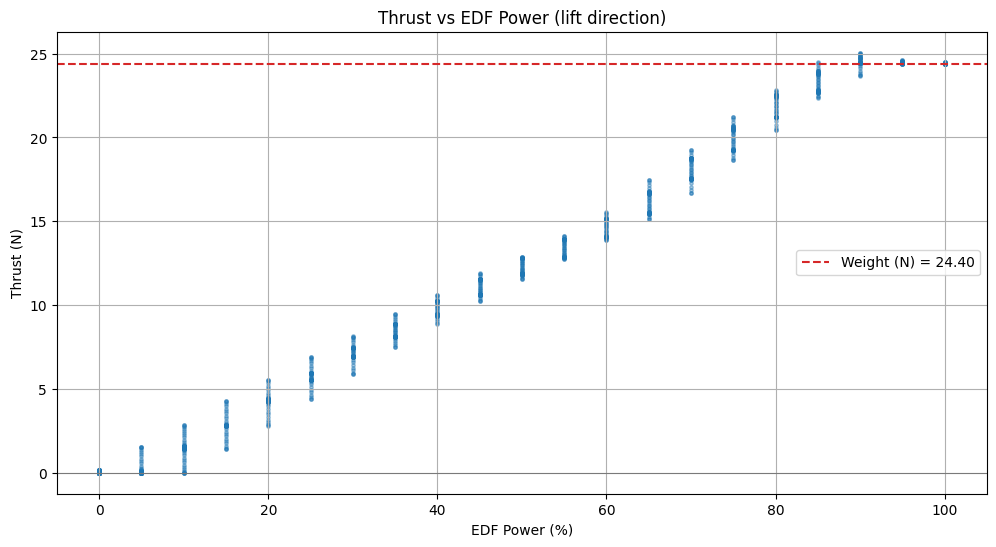

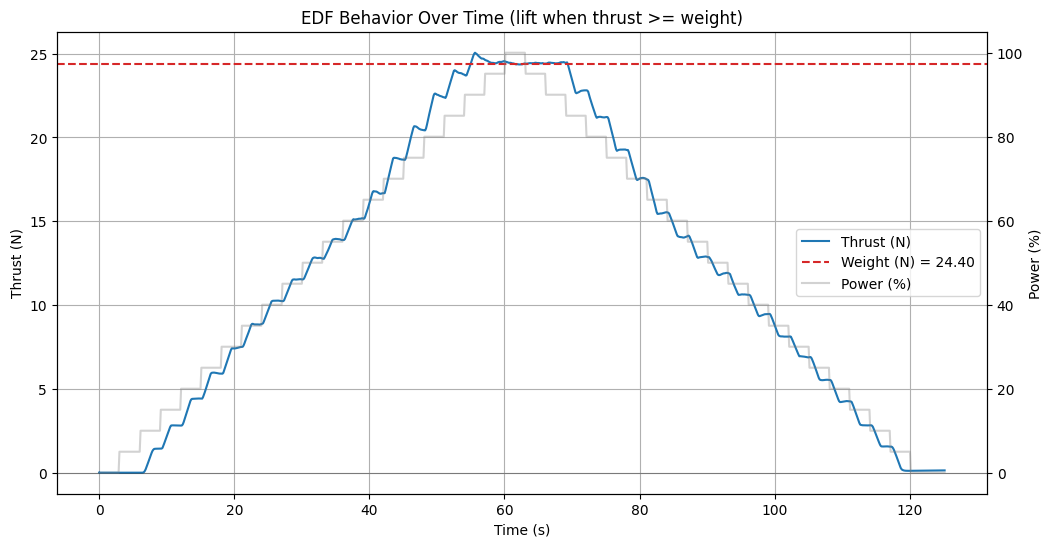

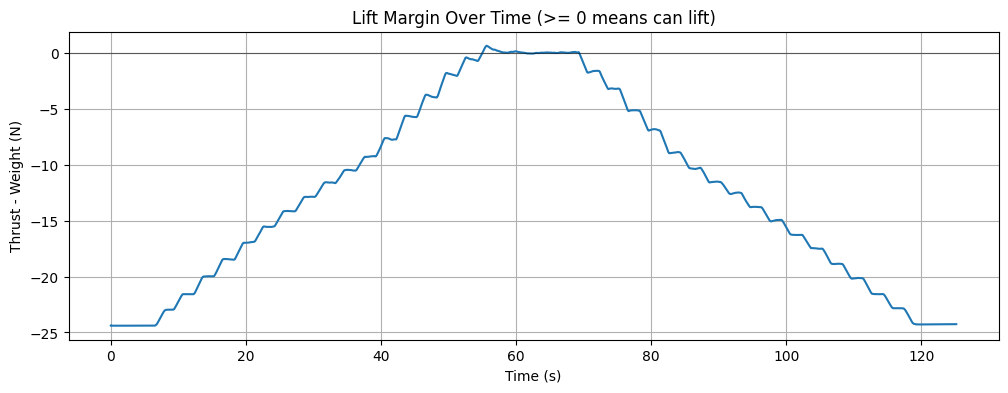

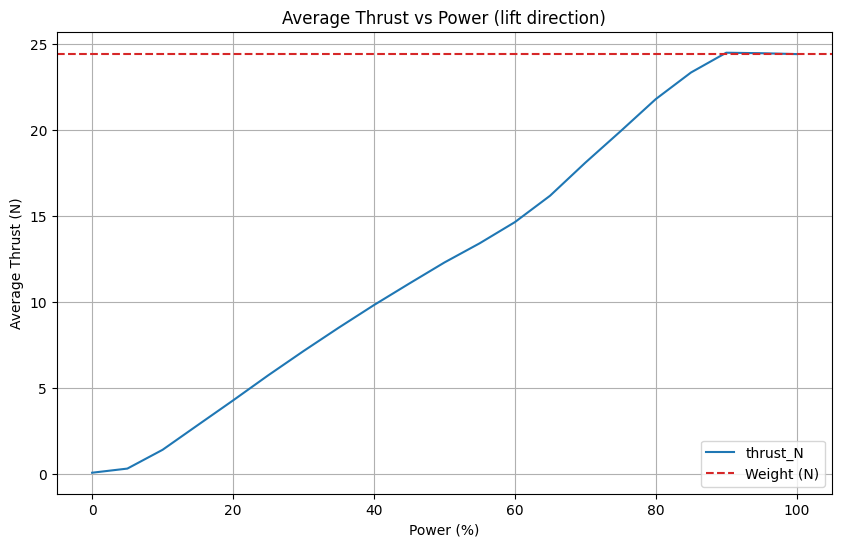

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load converted data (includes thrust_N)
df = pd.read_csv("Meritve/20260610_1_edf_motor_characterization_newtons.csv")

# Convert time to relative
df["time_s"] = df["pc_time_s"] - df["pc_time_s"].iloc[0]

tare_force_N = float(df["tare_force_N"].iloc[0]) if "tare_force_N" in df.columns else None

# Plot thrust vs power
plt.figure(figsize=(12, 6))
plt.scatter(
    df["edf_power_percent"],
    df["thrust_N"],
    s=6,
    alpha=0.4,
)

if tare_force_N is not None:
    plt.axhline(tare_force_N, color="tab:red", linestyle="--", label=f"Weight (N) = {tare_force_N:.2f}")
plt.axhline(0, color="k", linewidth=0.8, alpha=0.3)

plt.title("Thrust vs EDF Power (lift direction)")
plt.xlabel("EDF Power (%)")
plt.ylabel("Thrust (N)")
if tare_force_N is not None:
    plt.legend(loc="best")
plt.grid(True)
plt.show()

# Time series plot + lift threshold
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df["time_s"], df["thrust_N"], label="Thrust (N)", color="tab:blue")
if tare_force_N is not None:
    ax1.axhline(tare_force_N, color="tab:red", linestyle="--", label=f"Weight (N) = {tare_force_N:.2f}")
ax1.axhline(0, color="k", linewidth=0.8, alpha=0.3)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Thrust (N)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df["time_s"], df["edf_power_percent"], label="Power (%)", color="tab:gray", alpha=0.35)
ax2.set_ylabel("Power (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("EDF Behavior Over Time (lift when thrust >= weight)")
plt.show()

# Lift-off margin (thrust - weight)
if tare_force_N is not None:
    df["lift_margin_N"] = df["thrust_N"] - tare_force_N
    plt.figure(figsize=(12, 4))
    plt.plot(df["time_s"], df["lift_margin_N"], label="Lift margin (N)")
    plt.axhline(0, color="k", linewidth=0.8, alpha=0.5)
    plt.title("Lift Margin Over Time (>= 0 means can lift)")
    plt.xlabel("Time (s)")
    plt.ylabel("Thrust - Weight (N)")
    plt.grid(True)
    plt.show()

# Average thrust per power step
avg_thrust = df.groupby("edf_power_percent")["thrust_N"].mean()

plt.figure(figsize=(10, 6))
avg_thrust.plot()
if tare_force_N is not None:
    plt.axhline(tare_force_N, color="tab:red", linestyle="--", label="Weight (N)")
plt.title("Average Thrust vs Power (lift direction)")
plt.xlabel("Power (%)")
plt.ylabel("Average Thrust (N)")
if tare_force_N is not None:
    plt.legend(loc="best")
plt.grid(True)
plt.show()


In [24]:
# Lookup table for later use (steady-state average per step)
# We average only the last N samples of each step to avoid transient/ramp effects.
# Uses `thrust_lift_N` when available (clipped at 0), otherwise uses `thrust_N`.
thrust_col = "thrust_lift_N" if "thrust_lift_N" in df.columns else "thrust_N"
tail_n = 10  # last N samples per step

df_steps = df[df["step_index"] >= 0].copy() if "step_index" in df.columns else df.copy()
if "transition_flag" in df_steps.columns:
    df_steps = df_steps[df_steps["transition_flag"] == 0]

df_steps = df_steps.sort_values(["step_index", "pc_time_s"], kind="stable")
tail_df = df_steps.groupby("step_index", sort=True).tail(tail_n)

step_summary = (
    tail_df.groupby("step_index", sort=True)
    .agg(
        edf_power_percent=("edf_power_percent", "last"),
        thrust_N=(thrust_col, "mean"),
        n_samples=(thrust_col, "size"),
    )
    .reset_index(drop=True)
)

lut = step_summary.groupby("edf_power_percent")["thrust_N"].mean().sort_index()

powers = [int(p) for p in lut.index]
thrusts = [float(t) for t in lut.values]
print("powers:", powers)
print("thrusts:", thrusts)


powers: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
thrusts: [0.06762417407922408, 0.06199938765833135, 1.4870163270250059, 2.8220078068660897, 4.338058372464361, 5.737036238222716, 7.180973205417153, 8.485392413776582, 9.842832848687777, 11.080112371355456, 12.346011315197476, 13.40126208779037, 14.599989948159616, 16.096268620586585, 18.143385379673987, 19.900397413604814, 21.85170647947885, 23.306737176514368, 24.629259153671416, 24.469001670794576, 24.37591206285814]
